# ============================================================
# 🩺 SYSTÈME DE PRÉDICTION DU DIABÈTE
# Projet Machine Learning — Classification binaire
# ====================================================

**Objectif :** Prédire si un patient est diabétique à partir de caractéristiques médicales.  
**Modèle retenu :** AdaBoost  

**1.Importation des biblio**

In [625]:
import pandas as pd
import numpy as np
import gradio as gr
import os
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


**2.Importer le dataset**

In [626]:
df=pd.read_csv('/content/DATA_DIABETE.csv')

**3.Analyse des donnees**

In [627]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diabetic
0,6,148,72,35,0,33.6,0.627,50.0,1
1,1,85,66,29,0,26.6,0.351,NaN,0
2,8,183,64,0,0,23.3,0.672,32.0,1
3,1,89,66,23,94,28.1,0.167,21.0,0
4,0,137,40,35,168,NaN,2.288,33.0,1


In [628]:
df.shape

(786, 9)

In [629]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 786 entries, 0 to 785
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               786 non-null    int64  
 1   Glucose                   786 non-null    int64  
 2   BloodPressure             786 non-null    int64  
 3   SkinThickness             786 non-null    int64  
 4   Insulin                   786 non-null    int64  
 5   BMI                       777 non-null    float64
 6   DiabetesPedigreeFunction  786 non-null    float64
 7   Age                       778 non-null    float64
 8   Diabetic                  786 non-null    int64  
dtypes: float64(3), int64(6)
memory usage: 55.4 KB


In [630]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Diabetic'],
      dtype='object')

In [631]:
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,float64
Diabetic,int64


**Statistiques descriptives**

In [632]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diabetic
count,786.000000,786.000000,786.000000,786.000000,786.000000,777.000000,786.000000,778.000000,786.000000
mean,3.860051,121.068702,69.013995,20.506361,81.314249,31.962033,0.471331,33.749357,0.354962
std,3.369894,31.966668,19.590094,16.014105,119.007699,7.926791,0.330771,13.778451,0.478806
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.241500,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,34.000000,32.000000,0.374500,29.000000,0.000000
75%,6.000000,140.000000,80.000000,32.000000,128.750000,36.600000,0.622750,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,152.000000,1.000000


**4.Variable Cible**

In [633]:
df['Diabetic'].value_counts()

,count
Diabetic,
0,507
1,279


Ce problème est un problème de classification, car la variable cible Diabetic possède deux classes :

0 : non diabétique
1 : diabétique

In [634]:
print(y.value_counts(normalize=True) * 100)

Diabetic
0    65.104167
1    34.895833
Name: proportion, dtype: float64


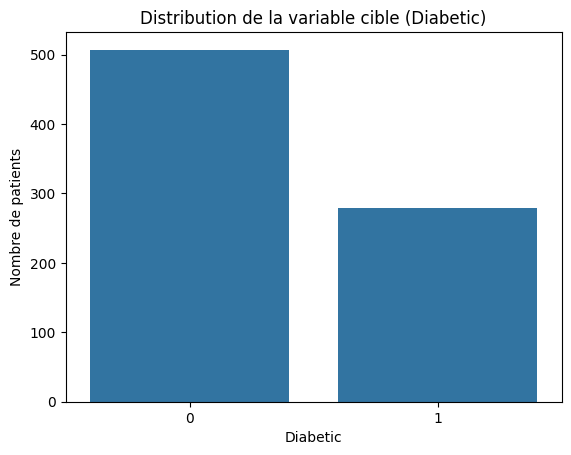

In [635]:
#Distribution de la variable cible
sns.countplot(x='Diabetic', data=df)
plt.title("Distribution de la variable cible (Diabetic)")
plt.xlabel("Diabetic")
plt.ylabel("Nombre de patients")
plt.show()


# Interprétation
Le dataset n'est pas parfaitement équilibré.

La classe 0 est majoritaire.

Cependant, le déséquilibre reste modéré, et non extrêmement important.

**5.Rechercher des valeurs manquantes**

In [636]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,9
DiabetesPedigreeFunction,0
Age,8
Diabetic,0


BMI    → 9 valeurs manquantes
Age    → 8 valeurs manquantes

**6.Rechercher des doublons**

In [637]:
df.duplicated().sum()

np.int64(18)

**supprimer les doublons**

In [638]:
df = df.drop_duplicates()

**vérification**

In [639]:
df.shape

(768, 9)

**7.Analyse des variables**

**Histogrammes**

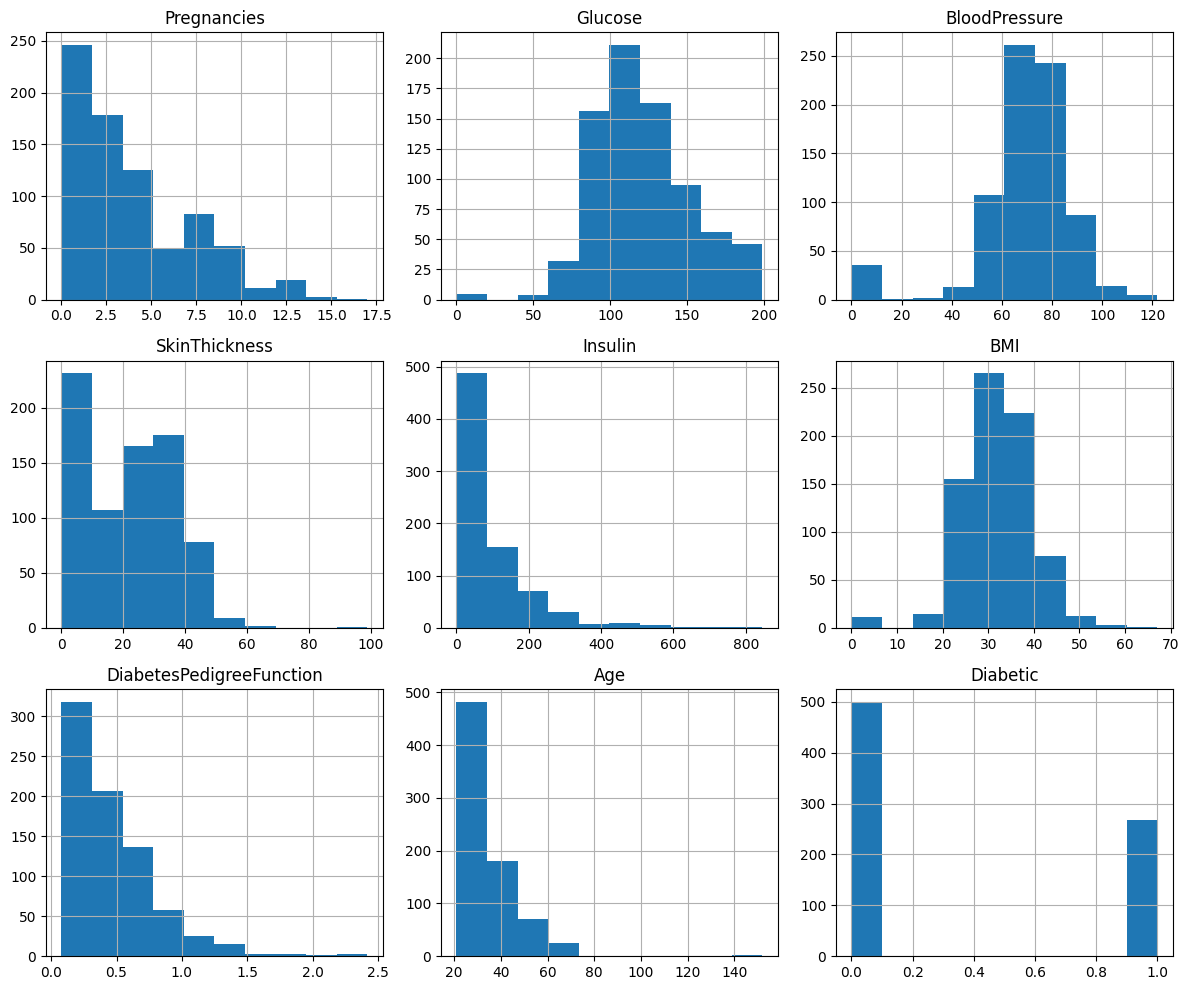

In [640]:
#Histogrammes de variables
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

# Interprétation
Les histogrammes permettent d'observer la distribution des variables.

Par exemple, on peut voir si une variable :

est concentrée autour d'une valeur
est asymétrique
contient des valeurs extrêmes
présente plusieurs groupes

**8.Heatmap de corrélation**

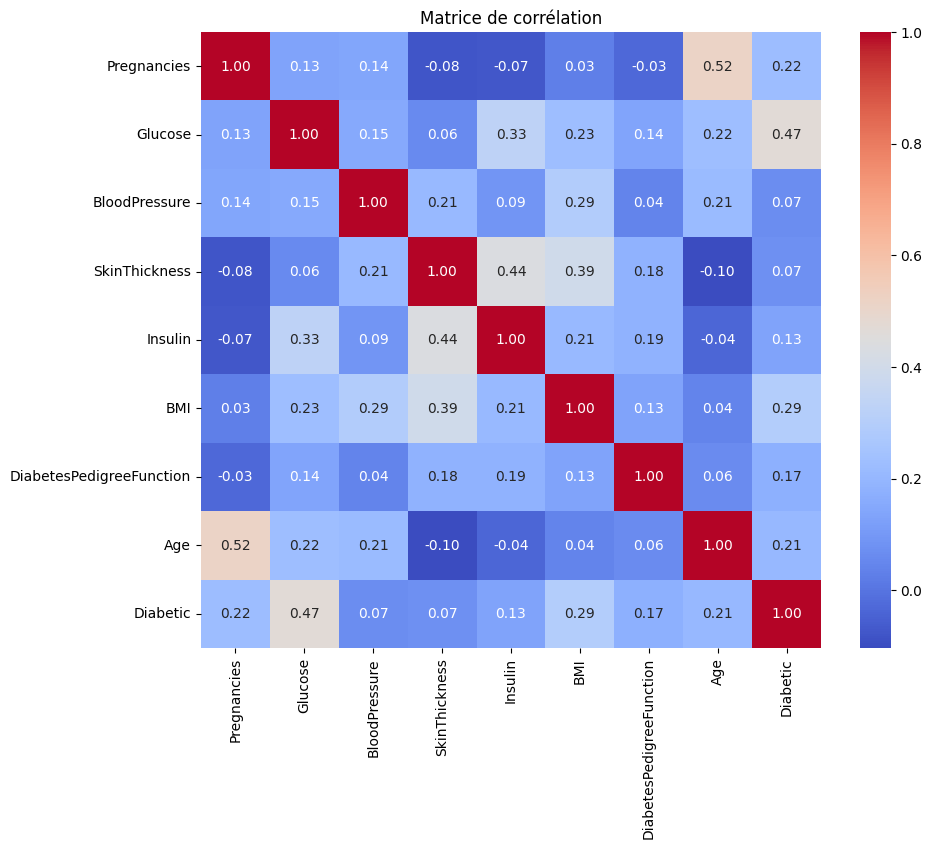

In [641]:
# Heatmap de corrélation
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de corrélation')
plt.show()

# Interprétation

La variable qui présente la plus forte corrélation avec le diabète dans ce dataset est : Glucose puis viennent notamment : BMI, Pregnancies et Age.



**9.Boxplots**

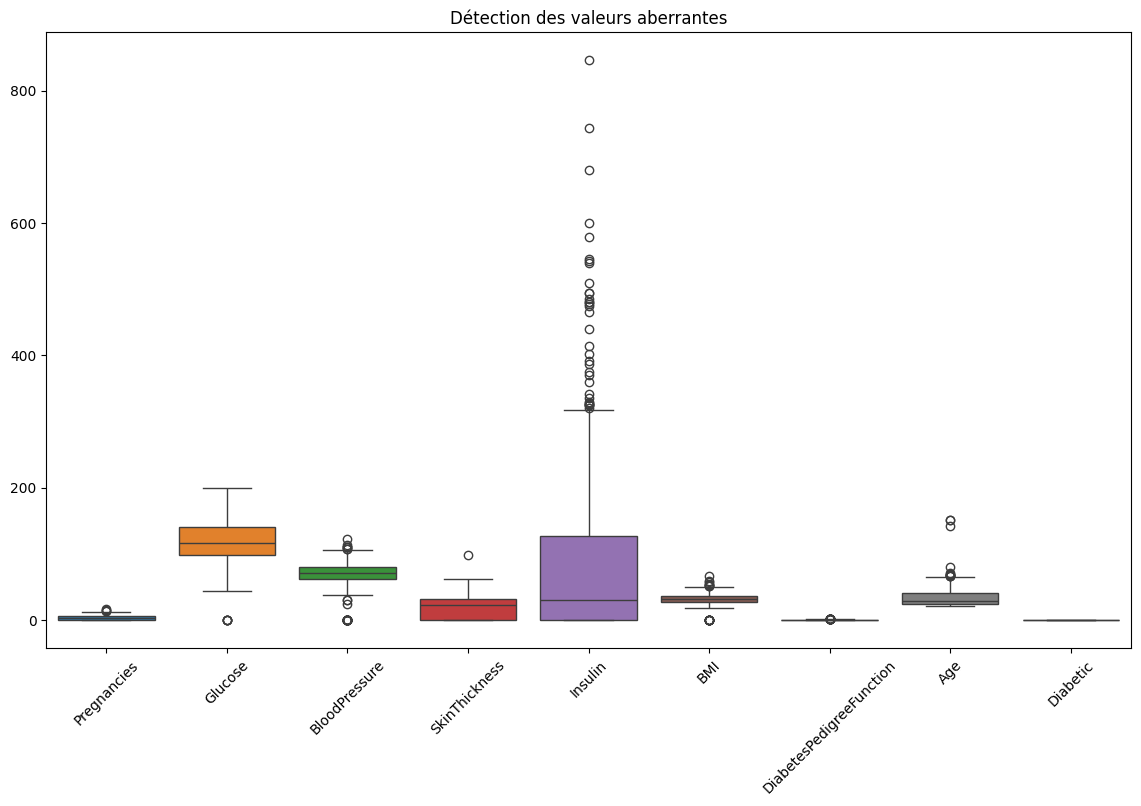

In [642]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Détection des valeurs aberrantes")
plt.show()

#Interpretation
Certaines variables présentent des valeurs extrêmes.
Par exemple :
Insulin → valeurs très élevées
Age → valeur 152 suspecte

**10.Feature Engineering**

la création de nouvelles features (une catégorie d'âge Age_Group)

In [643]:
# df["Age_Group"] = pd.cut(
    # df["Age"],
    # bins=[0, 25, 40, 60, 100],
    # labels=["Jeune", "Adulte", "Senior", "Âgé"]
# )

cette variable devient catégorielle, donc il faudrait ensuite l'encoder avant de l'utiliser dans certains modèles.

la création de nouvelles features (une catégorie d'du glucose)

In [644]:
# df["Glucose_Level"] = pd.cut(
    # df["Glucose"],
    # bins=[0, 100, 125, 200],
    # labels=["Normal", "Pré-diabète", "Élevé"]
# )

Une feature intéressante pourrait être une catégorisation du glucose mais attention pour l'entraînement de nos modèles actuels, nous pouvons conserver les variables numériques originales, car elles contiennent plus d'information.

**11.Séparation X / y**

In [645]:
X = df.drop("Diabetic", axis=1)
y = df["Diabetic"]

On sépare :
X = les variables explicatives du patient (âge, glucose, BMI, etc.)
y = la variable cible Diabetic que le modèle doit prédire.

**12.Séparation des données**

In [646]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

Pourquoi stratify=y ?

Parce que notre dataset est légèrement déséquilibré.

stratify=y permet de conserver approximativement la même proportion de classes dans :train et test

**13.Traitement des valeurs manquantes(Créer l'imputer)**

Méthode 1 : moyenne

In [647]:
#df['BMI'] = df['BMI'].fillna(df['BMI'].mean())
#df['Age'] = df['Age'].fillna(df['Age'].mean())

Méthode 2 : médiane

In [648]:
#df['BMI'] = df['BMI'].fillna(df['BMI'].mean())
#df["Age"] = df["Age"].fillna(df["Age"].median())

Méthode 3: les 5 voisins les plus proches

In [649]:
imputer = KNNImputer(n_neighbors=5)

# Apprendre l'imputation UNIQUEMENT sur le train
X_train_imputed = imputer.fit_transform(X_train)

# Appliquer la même transformation au test
X_test_imputed = imputer.transform(X_test)

# Reconvertir en DataFrame
X_train = pd.DataFrame(X_train_imputed, columns=X.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_imputed, columns=X.columns, index=X_test.index)


# Intérpretation

KNNImputer recherche les observations les plus proches pour estimer la valeur manquante.

n_neighbors=5 signifie que l'on utilise les 5 voisins les plus proches.

**Vérification finale**

In [650]:
# Vérifier qu'il n'y a plus de NaN
print("Valeurs manquantes dans X_train :", X_train.isnull().sum().sum())
print("Valeurs manquantes dans X_test :", X_test.isnull().sum().sum())

Valeurs manquantes dans X_train : 0
Valeurs manquantes dans X_test : 0


In [651]:
print("Doublons :", df.duplicated().sum())
print("Dimensions :", df.shape)

Doublons : 0
Dimensions : (768, 9)


**14.Standardisation**

Standardisation → transforme les données pour avoir une moyenne ≈ 0 et un écart-type ≈ 1

In [652]:
scaler = StandardScaler()

# Apprendre la moyenne et l'écart-type sur le train
X_train_scaled = scaler.fit_transform(X_train)

# Appliquer les mêmes paramètres au test
X_test_scaled = scaler.transform(X_test)

#Interpretation
On fait : fit_transform() sur X_train.

Mais seulement :transform() sur X_test.

Pour éviter le data leakage.

**15.Normalisation MinMaxScaler**

Normalisation (Min-Max) → transforme généralement les données dans l’intervalle [0, 1].

In [653]:
#scaler = MinMaxScaler()
#X_train_minmax = scaler.fit_transform(X_train)
#X_test_minmax = scaler.transform(X_test)

**16.Arbre de décision**

In [654]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [655]:
y_pred = model.predict(X_test)

In [656]:
#Evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1-score :", f1)

Accuracy : 0.6883116883116883
Precision : 0.5517241379310345
Recall : 0.5925925925925926
F1-score : 0.5714285714285714


In [657]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[74 26]
 [22 32]]


In [658]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.74      0.76       100
           1       0.55      0.59      0.57        54

    accuracy                           0.69       154
   macro avg       0.66      0.67      0.66       154
weighted avg       0.69      0.69      0.69       154



In [659]:
model.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

**17.GridSearchCV**

In [660]:
param_grid = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [3, 4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "class_weight": [None, "balanced"]
}

In [ ]:
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

In [ ]:
print(grid_search.best_params_)

**18.RandomizedSearchCV**

In [ ]:
from scipy.stats import randint

param_dist = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [3, 4, 5, 6, 8, 10, None],
    "min_samples_split": randint(2, 31),
    "min_samples_leaf": randint(1, 16),
    "class_weight": [None, "balanced"]
}

In [ ]:
random_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

In [ ]:
print(random_search.best_params_)

**19.Comparaison avec d'autres algorithmes**

**1.KNN**

In [ ]:
knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)
print("Accuracy :", accuracy_score(y_test, pred_knn))
print("Precision :", precision_score(y_test, pred_knn))
print("Recall :", recall_score(y_test, pred_knn))
print("F1-score :", f1_score(y_test, pred_knn))

**2.Random Forest**

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
print("Accuracy :", accuracy_score(y_test, pred_rf))
print("Precision :", precision_score(y_test, pred_rf))
print("Recall :", recall_score(y_test, pred_rf))
print("F1-score :", f1_score(y_test, pred_rf))

**3.Logistic Regression**

In [ ]:
lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
print("Accuracy :", accuracy_score(y_test, pred_lr))
print("Precision :", precision_score(y_test, pred_lr))
print("Recall :", recall_score(y_test, pred_lr))
print("F1-score :", f1_score(y_test, pred_lr))

**4.AdaBoost**

In [ ]:
ada = AdaBoostClassifier(random_state=42)
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)

print("=== RÉSULTATS DU MODÈLE ADABOOST ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")
print("\nMatrice de confusion:")
print(confusion_matrix(y_test, y_pred))

#Interprétation

Sur ce split précis, AdaBoost obtient les meilleures performances globales parmi les modèles testés.

Mais attention : Cela ne signifie pas qu'AdaBoost est universellement le meilleur modèle.

**20.Interface Gradio**

In [ ]:
# Nom du fichier pour persister l'historique
HISTORY_FILE = "diabetes_history.csv"

def load_history():
    """Charge l'historique depuis le fichier CSV"""
    if os.path.exists(HISTORY_FILE):
        return pd.read_csv(HISTORY_FILE)
    else:
        return pd.DataFrame(columns=[
            "Timestamp", "Patient", "Pregnancies", "Glucose", "BloodPressure",
            "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction",
            "Age", "Prediction", "Probability"
        ])

def save_history(df):
    """Sauvegarde l'historique dans le fichier CSV"""
    df.to_csv(HISTORY_FILE, index=False)

def predict_diabetes(
    patient_name,
    pregnancies,
    glucose,
    blood_pressure,
    skin_thickness,
    insulin,
    bmi,
    diabetes_pedigree,
    age
):
    # Charger l'historique existant
    history_df = load_history()

    patient = pd.DataFrame([[
        pregnancies,
        glucose,
        blood_pressure,
        skin_thickness,
        insulin,
        bmi,
        diabetes_pedigree,
        age
    ]], columns=[
        "Pregnancies",
        "Glucose",
        "BloodPressure",
        "SkinThickness",
        "Insulin",
        "BMI",
        "DiabetesPedigreeFunction",
        "Age"
    ])

    prediction = ada.predict(patient)[0]
    probability = ada.predict_proba(patient)[0][1]

    # Nom par défaut si vide
    nom = patient_name if patient_name and str(patient_name).strip() else "Anonyme"

    # Créer une nouvelle entrée pour l'historique
    new_entry = pd.DataFrame({
        "Timestamp": [datetime.now().strftime("%Y-%m-%d %H:%M:%S")],
        "Patient": [nom],
        "Pregnancies": [pregnancies],
        "Glucose": [glucose],
        "BloodPressure": [blood_pressure],
        "SkinThickness": [skin_thickness],
        "Insulin": [insulin],
        "BMI": [bmi],
        "DiabetesPedigreeFunction": [diabetes_pedigree],
        "Age": [age],
        "Prediction": ["DIABÉTIQUE" if prediction == 1 else "NON DIABÉTIQUE"],
        "Probability": [f"{probability*100:.2f}%" if prediction == 1 else f"{(1-probability)*100:.2f}%"]
    })

    # Ajouter à l'historique et sauvegarder
    history_df = pd.concat([history_df, new_entry], ignore_index=True)
    save_history(history_df)

    if prediction == 1:
        result = "🔴 DIABÉTIQUE"
        message = f"Probabilité estimée : {probability*100:.2f} %"
    else:
        result = "🟢 NON DIABÉTIQUE"
        message = f"Probabilité estimée : {(1-probability)*100:.2f} %"

    # Créer le tableau d'historique pour l'affichage
    history_table = history_df.tail(10)  # Afficher les 10 dernières prédictions

    return result, message, history_table

def clear_history():
    """Fonction pour effacer l'historique"""
    if os.path.exists(HISTORY_FILE):
        os.remove(HISTORY_FILE)
    return pd.DataFrame(columns=[
        "Timestamp", "Patient", "Pregnancies", "Glucose", "BloodPressure",
        "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction",
        "Age", "Prediction", "Probability"
    ])

# Charger l'historique au démarrage
initial_history = load_history()

with gr.Blocks(title="Diabetes Prediction") as demo:

    gr.Markdown(
        """
        # 🩺 Diabetes Prediction
        ### Système de prédiction du diabète avec Machine Learning

        Entrez les données médicales du patient afin d'obtenir
        une prédiction à partir du modèle **AdaBoost**.
        """
    )
    patient_name = gr.Textbox(
        label="Nom du patient",
        placeholder="Ex: Jean Dupont",
        value=""
    )

    with gr.Row():

        with gr.Column():

            pregnancies = gr.Number(
                label="Pregnancies"
            )

            glucose = gr.Number(
                label="Glucose"
            )

            blood_pressure = gr.Number(
                label="Blood Pressure"
            )

            skin_thickness = gr.Number(
                label="Skin Thickness"
            )

        with gr.Column():

            insulin = gr.Number(
                label="Insulin"
            )

            bmi = gr.Number(
                label="BMI"
            )

            diabetes_pedigree = gr.Number(
                label="Diabetes Pedigree Function"
            )

            age = gr.Number(
                label="Age"
            )

    predict_button = gr.Button(
        "Prédire le diabète",
        variant="primary"
    )

    clear_button = gr.Button(
        "🗑️ Effacer l'historique",
        variant="secondary"
    )

    result = gr.Textbox(
        label="Résultat",
        interactive=False
    )

    probability = gr.Textbox(
        label="Probabilité",
        interactive=False
    )

    history_table = gr.Dataframe(
        value=initial_history,
        label="Historique des prédictions (10 dernières)",
        interactive=False
    )

    predict_button.click(
        fn=predict_diabetes,
        inputs=[
            patient_name,
            pregnancies,
            glucose,
            blood_pressure,
            skin_thickness,
            insulin,
            bmi,
            diabetes_pedigree,
            age
        ],
        outputs=[
            result,
            probability,
            history_table
        ]
    )

    clear_button.click(
        fn=clear_history,
        inputs=[],
        outputs=[history_table]
    )

demo.launch()